# Modelo xG Propio

Construcción de un modelo de Expected Goals (xG) desde cero usando regresión logística.

## ¿Qué es xG?

xG (Expected Goals) es la probabilidad de que un tiro termine en gol, basada en sus características: distancia al arco, ángulo, parte del cuerpo, tipo de jugada, etc.

Un penal tiene xG ≈ 0.78 (78% de probabilidad de gol).  
Un tiro desde 30 metros tiene xG ≈ 0.02 (2% de probabilidad).  
Un mano a mano tiene xG ≈ 0.40.

## Objetivo

Entrenar un modelo que aprenda estos patrones a partir de ~5,000-10,000 tiros históricos de torneos profesionales, y comparar su rendimiento con el xG oficial de StatsBomb.

## 1. Setup

Importamos las librerías necesarias.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsbombpy import sb
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
print("Setup OK")

Setup OK


## 2. Selección de torneos

Para entrenar un modelo robusto necesitamos muchos tiros de diferentes contextos (selecciones, ligas, distintas épocas). Seleccionamos 5 torneos con datos abiertos de StatsBomb.

In [12]:
competitions = sb.competitions()
print(f"Total competiciones disponibles: {len(competitions)}")
competitions[['competition_id', 'season_id', 'competition_name', 'season_name']].head(20)

Total competiciones disponibles: 75


,competition_id,season_id,competition_name,season_name
0,9,281,1. Bundesliga,2023/2024
1,9,27,1. Bundesliga,2015/2016
2,1267,107,African Cup of Nations,2023
3,16,4,Champions League,2018/2019
4,16,1,Champions League,2017/2018
5,16,2,Champions League,2016/2017
6,16,27,Champions League,2015/2016
7,16,26,Champions League,2014/2015
8,16,25,Champions League,2013/2014
9,16,24,Champions League,2012/2013


In [13]:
# Lista de torneos para entrenar el modelo
# Formato: (competition_id, season_id, nombre)
torneos = [
    (43, 106, 'Mundial 2022'),
    (43, 3, 'Mundial 2018'),
    (55, 282, 'Eurocopa 2024'),
    (55, 43, 'Eurocopa 2020'),
    (11, 90, 'LaLiga 2020-21'),
]

print(f"Vamos a procesar {len(torneos)} torneos")

Vamos a procesar 5 torneos


## 3. Extracción de tiros

Definimos una función que recorre todos los partidos de un torneo y extrae únicamente los eventos de tipo "Shot" (tiro). Cada tiro viene con decenas de atributos: ubicación, jugador, parte del cuerpo, tipo de jugada, xG de StatsBomb, etc.

In [14]:
def extraer_tiros_torneo(competition_id, season_id, nombre_torneo):
    """
    Extrae todos los tiros de un torneo completo.
    Retorna un DataFrame con todos los tiros y sus características.
    """
    print(f"\nProcesando: {nombre_torneo}")
    
    # Cargar partidos del torneo
    matches = sb.matches(competition_id=competition_id, season_id=season_id)
    print(f"  Partidos: {len(matches)}")
    
    tiros_totales = []
    
    # Iterar sobre cada partido
    for match_id in tqdm(matches['match_id'], desc=f"  Cargando"):
        try:
            events = sb.events(match_id=match_id)
            tiros = events[events['type'] == 'Shot'].copy()
            
            if len(tiros) > 0:
                tiros['torneo'] = nombre_torneo
                tiros['match_id'] = match_id
                tiros_totales.append(tiros)
        except Exception as e:
            print(f"  Error en partido {match_id}: {e}")
            continue
    
    if tiros_totales:
        return pd.concat(tiros_totales, ignore_index=True)
    return pd.DataFrame()

## 4. Ejecución de la extracción

Esta celda recorre los 5 torneos seleccionados. Tarda entre 5 y 15 minutos porque carga cada partido individualmente desde la API de StatsBomb.

In [10]:
# Extraer tiros de todos los torneos
todos_los_tiros = []

for comp_id, season_id, nombre in torneos:
    tiros = extraer_tiros_torneo(comp_id, season_id, nombre)
    if len(tiros) > 0:
        todos_los_tiros.append(tiros)
        print(f"  ✓ {nombre}: {len(tiros)} tiros extraídos")

# Combinar todo
tiros_df = pd.concat(todos_los_tiros, ignore_index=True)
print(f"\n=== TOTAL DE TIROS: {len(tiros_df)} ===")


Procesando: Mundial 2022
  Partidos: 64


  Cargando: 100%|██████████| 64/64 [00:40<00:00,  1.59it/s]


  ✓ Mundial 2022: 1494 tiros extraídos

Procesando: Mundial 2018
  Partidos: 64


  Cargando: 100%|██████████| 64/64 [00:36<00:00,  1.76it/s]


  ✓ Mundial 2018: 1706 tiros extraídos

Procesando: Eurocopa 2024
  Partidos: 51


...

  ✓ Eurocopa 2024: 1340 tiros extraídos

Procesando: Eurocopa 2020
  Partidos: 51


  Cargando: 100%|██████████| 51/51 [00:44<00:00,  1.14it/s]


  ✓ Eurocopa 2020: 1289 tiros extraídos

Procesando: LaLiga 2020-21
  Partidos: 35


  Cargando: 100%|██████████| 35/35 [00:28<00:00,  1.23it/s]

  ✓ LaLiga 2020-21: 839 tiros extraídos

=== TOTAL DE TIROS: 6668 ===


## 5. Validación de los datos extraídos

Revisamos cuántos tiros tenemos por torneo, cuántos terminaron en gol y la tasa de conversión general. La tasa típica en fútbol profesional está entre 9% y 12%.

In [15]:
print("Tiros por torneo:")
print(tiros_df['torneo'].value_counts())

print(f"\nTotal de goles: {(tiros_df['shot_outcome'] == 'Goal').sum()}")
print(f"Tasa de conversión: {(tiros_df['shot_outcome'] == 'Goal').mean() * 100:.1f}%")

Tiros por torneo:
torneo
Mundial 2018      1706
Mundial 2022      1494
Eurocopa 2024     1340
Eurocopa 2020     1289
LaLiga 2020-21     839
Name: count, dtype: int64

Total de goles: 770
Tasa de conversión: 11.5%


## 6. Guardar los datos crudos

Guardamos el dataset en formato Parquet. Esto evita tener que descargar todo de nuevo si reiniciamos el kernel.

In [18]:
tiros_df.to_csv('../data/processed/tiros_raw.csv', index=False)
print(f"Guardado: ../data/processed/tiros_raw.csv")
print(f"Tamaño: {len(tiros_df)} tiros")

Guardado: ../data/processed/tiros_raw.csv
Tamaño: 6668 tiros


## 7. Construcción de features

De cada tiro extraemos las características que el modelo usará para predecir si fue gol:

- **Distancia al arco**: distancia euclidiana desde el punto del tiro hasta el centro del arco
- **Ángulo del tiro**: ángulo de visión del arco desde el punto del tiro (a mayor ángulo, más fácil meter gol)
- **Parte del cuerpo**: pie o cabeza
- **Tipo de jugada**: juego abierto, córner, tiro libre, penal
- **Bajo presión**: si había defensores cercanos al momento del tiro

En StatsBomb, el arco está en la coordenada (120, 40). El campo va de 0 a 120 en X y de 0 a 80 en Y.

In [19]:
tiros_df = pd.read_csv('../data/processed/tiros_raw.csv')
print(f"Tiros cargados: {len(tiros_df)}")

Tiros cargados: 6668


In [20]:
import ast

def parsear_location(loc):
    """Convierte string '[x, y]' a lista [x, y]. Si ya es lista, la deja."""
    if isinstance(loc, list):
        return loc
    if isinstance(loc, str):
        try:
            return ast.literal_eval(loc)
        except:
            return None
    return None

# Coordenadas del arco en StatsBomb
ARCO_X = 120
ARCO_Y = 40
ANCHO_ARCO = 7.32  # metros, ancho oficial del arco

def calcular_features(df):
    """Construye features a partir de los datos crudos de tiros."""
    df = df.copy()
    
    # Parsear location si viene como string
    df['location_parsed'] = df['location'].apply(parsear_location)
    
    # Filtrar tiros sin ubicación válida
    df = df[df['location_parsed'].notna()].copy()
    
    # Extraer coordenadas
    df['x'] = df['location_parsed'].apply(lambda l: l[0] if isinstance(l, list) and len(l) >= 2 else None)
    df['y'] = df['location_parsed'].apply(lambda l: l[1] if isinstance(l, list) and len(l) >= 2 else None)
    df = df.dropna(subset=['x', 'y'])
    
    # Feature 1: Distancia al arco
    df['distancia'] = np.sqrt((ARCO_X - df['x'])**2 + (ARCO_Y - df['y'])**2)
    
    # Feature 2: Ángulo del tiro
    # Fórmula: ángulo entre las líneas del tirador a cada palo
    df['angulo'] = np.arctan(
        (ANCHO_ARCO * (ARCO_X - df['x'])) /
        ((ARCO_X - df['x'])**2 + (ARCO_Y - df['y'])**2 - (ANCHO_ARCO/2)**2)
    )
    df['angulo'] = np.where(df['angulo'] < 0, df['angulo'] + np.pi, df['angulo'])
    
    # Feature 3: Parte del cuerpo (simplificada)
    df['es_cabeza'] = (df['shot_body_part'] == 'Head').astype(int)
    
    # Feature 4: Tipo de jugada
    df['es_penal'] = (df['shot_type'] == 'Penalty').astype(int)
    df['es_tiro_libre'] = (df['shot_type'] == 'Free Kick').astype(int)
    df['es_corner'] = (df['shot_type'] == 'Corner').astype(int)
    df['es_juego_abierto'] = (df['shot_type'] == 'Open Play').astype(int)
    
    # Feature 5: Bajo presión
    df['bajo_presion'] = df['under_pressure'].fillna(False).astype(int)
    
    # Variable objetivo: ¿fue gol?
    df['es_gol'] = (df['shot_outcome'] == 'Goal').astype(int)
    
    return df

tiros_features = calcular_features(tiros_df)
print(f"Tiros con features: {len(tiros_features)}")

Tiros con features: 6668


## 8. Exploración de los features

Antes de entrenar el modelo, validamos que los features hacen sentido futbolístico.

In [21]:
# Resumen estadístico de los features
features_cols = ['distancia', 'angulo', 'es_cabeza', 'es_penal', 
                  'es_tiro_libre', 'es_juego_abierto', 'bajo_presion', 'es_gol']
print(tiros_features[features_cols].describe().round(3))

       distancia    angulo  es_cabeza  es_penal  es_tiro_libre  \
count   6668.000  6668.000   6668.000  6668.000       6668.000   
mean      18.472     0.420      0.167     0.035          0.040   
std        8.407     0.266      0.373     0.184          0.196   
min        0.762     0.000      0.000     0.000          0.000   
25%       11.900     0.247      0.000     0.000          0.000   
50%       17.720     0.327      0.000     0.000          0.000   
75%       24.500     0.535      0.000     0.000          0.000   
max       80.203     3.141      1.000     1.000          1.000   

       es_juego_abierto  bajo_presion    es_gol  
count          6668.000      6668.000  6668.000  
mean              0.924         0.212     0.115  
std               0.265         0.408     0.320  
min               0.000         0.000     0.000  
25%               1.000         0.000     0.000  
50%               1.000         0.000     0.000  
75%               1.000         0.000     0.000  
max  

In [22]:
# Tasa de gol por rangos de distancia
tiros_features['rango_distancia'] = pd.cut(
    tiros_features['distancia'],
    bins=[0, 6, 12, 18, 24, 30, 50],
    labels=['0-6m', '6-12m', '12-18m', '18-24m', '24-30m', '30m+']
)

print("Tasa de gol por distancia al arco:")
print(tiros_features.groupby('rango_distancia', observed=True)['es_gol'].agg(['count', 'mean']).round(3))

Tasa de gol por distancia al arco:
                 count   mean
rango_distancia              
0-6m               207  0.425
6-12m             1626  0.229
12-18m            1578  0.116
18-24m            1443  0.050
24-30m            1243  0.036
30m+               552  0.014


In [23]:
# Tasa de gol por tipo de jugada
print("Tasa de gol por tipo de jugada:")
print(tiros_features.groupby('shot_type')['es_gol'].agg(['count', 'mean']).round(3))

Tasa de gol por tipo de jugada:
           count   mean
shot_type              
Corner         6  0.000
Free Kick    266  0.049
Open Play   6161  0.097
Penalty      235  0.685


## 9. División train/test

Separamos los datos en dos grupos:
- **Train (80%)**: para entrenar el modelo
- **Test (20%)**: para evaluar qué tan bien predice tiros que nunca vio

Esta separación es fundamental: si evaluáramos el modelo con los mismos datos con los que aprendió, nos engañaríamos a nosotros mismos.

In [24]:
from sklearn.model_selection import train_test_split

# Features que usaremos
features = ['distancia', 'angulo', 'es_cabeza', 'es_penal', 
            'es_tiro_libre', 'es_juego_abierto', 'bajo_presion']

X = tiros_features[features]
y = tiros_features['es_gol']

# División 80/20 con semilla fija para reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} tiros ({y_train.mean()*100:.1f}% goles)")
print(f"Test:  {len(X_test)} tiros ({y_test.mean()*100:.1f}% goles)")

Train: 5334 tiros (11.5% goles)
Test:  1334 tiros (11.5% goles)


## 10. Entrenamiento del modelo

Usamos regresión logística. Le pasamos los features de los 5,334 tiros de train y el modelo aprende qué combinación de características predice mejor un gol.

In [25]:
from sklearn.linear_model import LogisticRegression

# Crear y entrenar el modelo
modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente")
print(f"\nCoeficientes aprendidos:")
for feat, coef in zip(features, modelo.coef_[0]):
    print(f"  {feat}: {coef:+.4f}")
print(f"  Intercepto: {modelo.intercept_[0]:+.4f}")

Modelo entrenado correctamente

Coeficientes aprendidos:
  distancia: -0.0943
  angulo: +1.5549
  es_cabeza: -0.9496
  es_penal: +1.1447
  es_tiro_libre: -0.4946
  es_juego_abierto: -0.9353
  bajo_presion: -0.5814
  Intercepto: -0.2821


## 11. Predicciones sobre el set de test

Calculamos el xG predicho por nuestro modelo para los 1,334 tiros del test set (tiros que el modelo nunca vio durante el entrenamiento).

In [26]:
# Predecir probabilidades de gol (esto es nuestro xG)
xg_predicho = modelo.predict_proba(X_test)[:, 1]

# Agregar las predicciones al set de test
X_test_resultados = X_test.copy()
X_test_resultados['es_gol_real'] = y_test
X_test_resultados['xg_mi_modelo'] = xg_predicho

print(f"Predicciones generadas: {len(xg_predicho)}")
print(f"\nDistribución del xG predicho:")
print(pd.Series(xg_predicho).describe().round(3))

Predicciones generadas: 1334

Distribución del xG predicho:
count    1334.000
mean        0.115
std         0.144
min         0.001
25%         0.038
50%         0.066
75%         0.125
max         0.923
dtype: float64


## 12. Evaluación: ¿qué tan bueno es nuestro modelo?

Comparamos las predicciones con la realidad. Si el modelo es bueno:
- Tiros con xG alto (>0.5) deberían ser gol frecuentemente
- Tiros con xG bajo (<0.1) raramente deberían serlo
- La suma de xG predicho debería aproximarse al total de goles real

In [27]:
# Comparación goles reales vs xG predicho
goles_reales = y_test.sum()
xg_total_predicho = xg_predicho.sum()

print(f"Goles reales en el test:     {goles_reales}")
print(f"xG total predicho:           {xg_total_predicho:.1f}")
print(f"Diferencia:                  {goles_reales - xg_total_predicho:.1f}")

Goles reales en el test:     154
xG total predicho:           153.4
Diferencia:                  0.6


In [28]:
# Tasa real de gol por bucket de xG predicho
X_test_resultados['bucket_xg'] = pd.cut(
    X_test_resultados['xg_mi_modelo'],
    bins=[0, 0.05, 0.10, 0.20, 0.40, 0.70, 1.0],
    labels=['<5%', '5-10%', '10-20%', '20-40%', '40-70%', '>70%']
)

calibracion = X_test_resultados.groupby('bucket_xg', observed=True).agg(
    tiros=('es_gol_real', 'count'),
    xg_promedio=('xg_mi_modelo', 'mean'),
    tasa_gol_real=('es_gol_real', 'mean')
).round(3)

print("Calibración del modelo:")
print(calibracion)

Calibración del modelo:
           tiros  xg_promedio  tasa_gol_real
bucket_xg                                   
<5%          490        0.031          0.024
5-10%        408        0.072          0.078
10-20%       266        0.138          0.143
20-40%        98        0.270          0.255
40-70%        68        0.624          0.676
>70%           4        0.832          0.250


## 13. Comparación con xG de StatsBomb

StatsBomb tiene su propio modelo de xG (industria líder). Lo usan clubes y casas de apuestas pagando licencias caras.

Nuestro modelo es mucho más simple (solo 7 features, regresión logística básica). El xG de StatsBomb usa decenas de features adicionales: ubicación del arquero, defensores entre el tirador y el arco, tipo de pase previo, etc.

A pesar de esa desventaja, podemos comparar qué tan cerca llegamos.

In [29]:
# Cargar el xG de StatsBomb para los mismos tiros del test
indices_test = X_test.index
tiros_test_completos = tiros_features.loc[indices_test].copy()

# Agregar mi xG al dataframe
tiros_test_completos['xg_mi_modelo'] = xg_predicho
tiros_test_completos['xg_statsbomb'] = tiros_test_completos['shot_statsbomb_xg']

# Filtrar tiros que tienen xG de StatsBomb (algunos pueden ser nulos)
comparacion = tiros_test_completos.dropna(subset=['xg_statsbomb']).copy()

print(f"Tiros con ambos xG: {len(comparacion)}")
print(f"\nTotales:")
print(f"  Goles reales:        {comparacion['es_gol'].sum()}")
print(f"  xG StatsBomb total:  {comparacion['xg_statsbomb'].sum():.1f}")
print(f"  xG Mi modelo total:  {comparacion['xg_mi_modelo'].sum():.1f}")

Tiros con ambos xG: 1334

Totales:
  Goles reales:        154
  xG StatsBomb total:  159.0
  xG Mi modelo total:  153.4


In [30]:
# Correlación entre ambos modelos
correlacion = comparacion[['xg_statsbomb', 'xg_mi_modelo']].corr().iloc[0, 1]
print(f"Correlación mi xG vs StatsBomb xG: {correlacion:.3f}")

# Diferencia promedio
diff = (comparacion['xg_mi_modelo'] - comparacion['xg_statsbomb']).abs().mean()
print(f"Diferencia absoluta promedio por tiro: {diff:.3f}")

Correlación mi xG vs StatsBomb xG: 0.893
Diferencia absoluta promedio por tiro: 0.042


## 14. Visualización: Mi xG vs StatsBomb xG

Un scatter plot que muestra qué tan alineadas están las predicciones de ambos modelos.

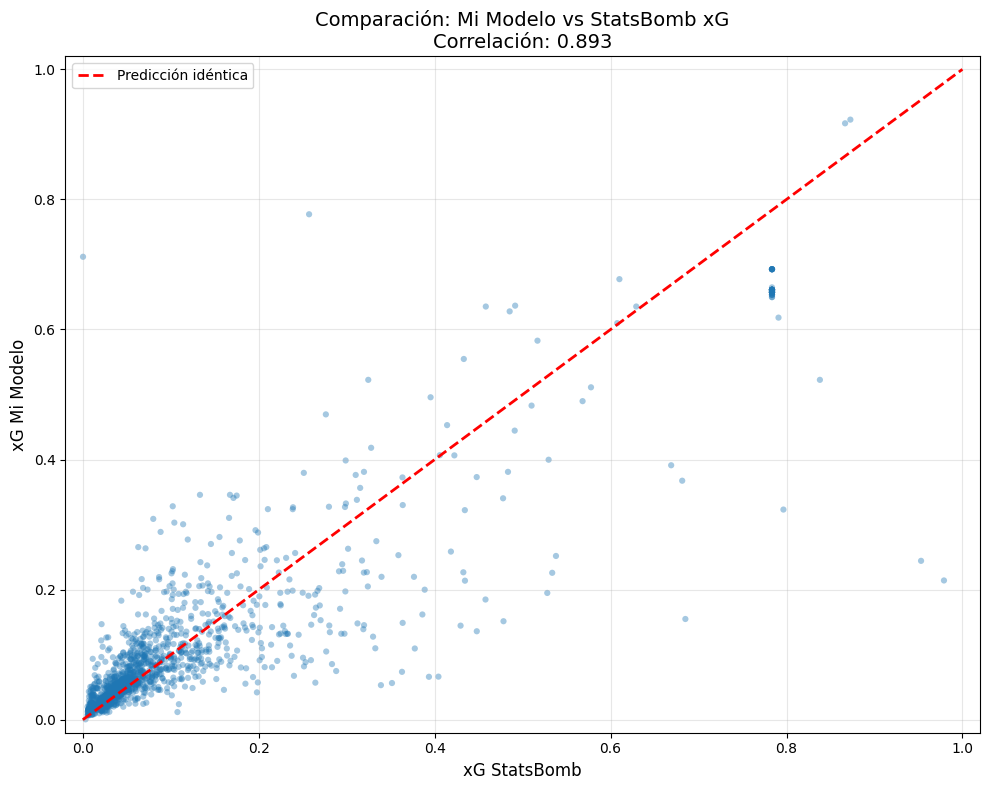

In [31]:
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot
ax.scatter(
    comparacion['xg_statsbomb'], 
    comparacion['xg_mi_modelo'],
    alpha=0.4, s=20, c='#1f77b4', edgecolors='none'
)

# Línea diagonal (predicción perfecta)
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Predicción idéntica')

ax.set_xlabel('xG StatsBomb', fontsize=12)
ax.set_ylabel('xG Mi Modelo', fontsize=12)
ax.set_title(f'Comparación: Mi Modelo vs StatsBomb xG\nCorrelación: {correlacion:.3f}', fontsize=14)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/comparacion_xg.png', dpi=150, bbox_inches='tight')
plt.show()